In [1]:
#Importing Liabraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [2]:
#Extracting CSV Dataset from System using Pandas Liabrary
data = pd.read_csv(r"C:\Users\sarth\Documents\DS_f proj\2_Health Screening Data.csv")

In [3]:
#Dataset Head Information
data.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,AgeinYr,BMI,BMICat,AgeGroup
0,0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,22.0,Normal,40-60
1,1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.9,Obese,40-60
2,2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.5,Normal,40-60
3,3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.7,Over Weight,40-60
4,4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.0,Normal,40-60


In [4]:
#All columns in a dataset
data.columns

Index(['Unnamed: 0', 'id', 'age', 'gender', 'height', 'weight', 'ap_hi',
       'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio',
       'AgeinYr', 'BMI', 'BMICat', 'AgeGroup'],
      dtype='object')

# **There are no missing values in dataset.**

In [1]:
#Checking NULL values
data.isnull().sum()

NameError: name 'data' is not defined

## **PERCENTAGE OF MALE VS FEMALE EMPLOYEES**

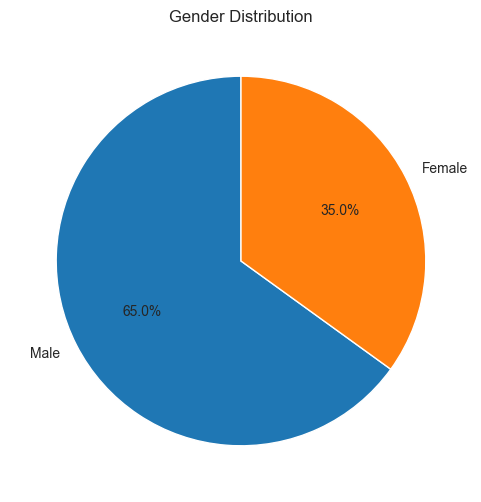

In [6]:
# Count the number of males and females
gender_counts = data['gender'].value_counts()

# Create labels and sizes for the pie chart
labels = ['Male', 'Female']
sizes = gender_counts.values

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.show()

# **AGE GROUPS VS CHOLESTEROL LEVELS**

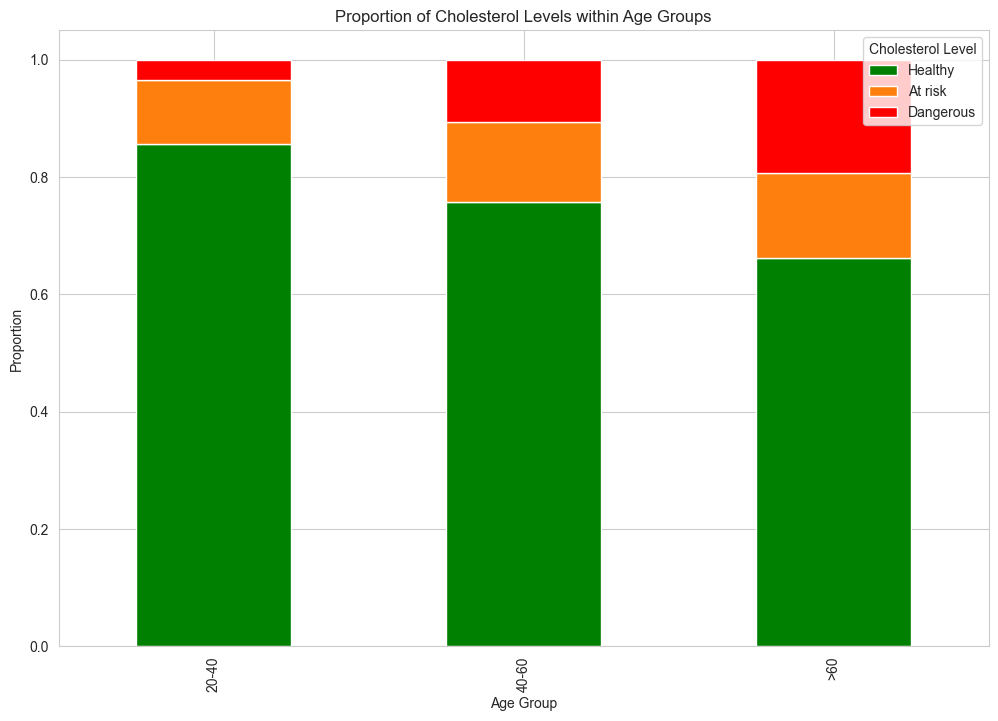

In [7]:

# Assuming 'data' is your DataFrame, replace it if necessary
df = data.copy()  # Create a copy to avoid modifying the original

# Stacked Bar Plot: Age Groups vs. Cholesterol Levels
age_cholesterol = df.groupby(['AgeGroup', 'cholesterol']).size().unstack()
age_cholesterol = age_cholesterol.div(age_cholesterol.sum(axis=1), axis=0)

age_cholesterol.plot(kind='bar', stacked=True, figsize=(12, 8), color=['green', '#ff7f0e', 'red'])
plt.title('Proportion of Cholesterol Levels within Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Proportion')
plt.legend(title='Cholesterol Level', labels=['Healthy', 'At risk', 'Dangerous'])
plt.show()


### **Here, the more young age employees have healthy cholesterol levels and the elder employees have more dangerous level of cholesterol as compared to other two age categories.**

# **AGE GROUP VS GLUCOSE LEVELS**

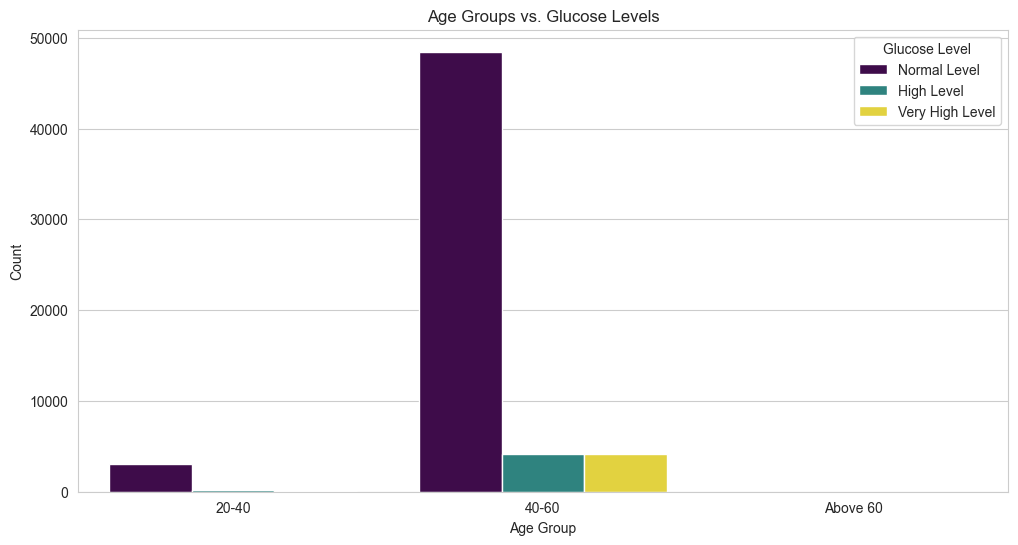

In [8]:

# Plot 1: Compare Age Groups with Glucose Levels
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='AgeGroup', hue='gluc', palette='viridis', order=['20-40', '40-60', 'Above 60'])
plt.title('Age Groups vs. Glucose Levels')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Glucose Level', loc='upper right', labels=['Normal Level', 'High Level ', 'Very High Level'])
plt.show()


### **Here, the age group of 20-40 has normal glucose level, age group of 40-60 has high glucose level and age group of above 60 has very high glucose level**

# **BLOOD PRESSURE DISTRIBUTION VS GENDER**

C:\Users\sarth\AppData\Local\Temp\ipykernel_7608\3854577752.py:6: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'gray'}` instead.

  sns.barplot(data=melted_data, x='variable', y='value', hue='gender', palette='Set2',
C:\Users\sarth\AppData\Local\Temp\ipykernel_7608\3854577752.py:6: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(data=melted_data, x='variable', y='value', hue='gender', palette='Set2',


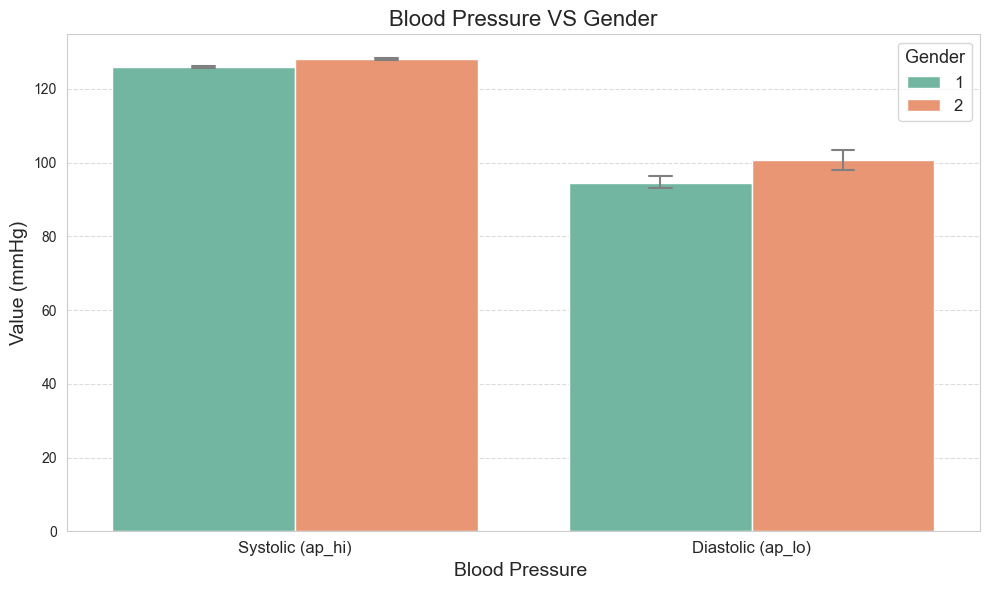

In [9]:
# Melt the DataFrame for blood pressure data
melted_data = pd.melt(data, id_vars=['gender'], value_vars=['ap_hi', 'ap_lo'])

# Plot grouped bar plots for blood pressure
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.barplot(data=melted_data, x='variable', y='value', hue='gender', palette='Set2',
            errcolor='gray', errwidth=1.5, capsize=0.1)
plt.title('Blood Pressure VS Gender', fontsize=16)
plt.xlabel('Blood Pressure ', fontsize=14)
plt.ylabel('Value (mmHg)', fontsize=14)  # Specify units
plt.xticks(ticks=[0, 1], labels=['Systolic (ap_hi)', 'Diastolic (ap_lo)'], fontsize=12)  # Custom x-tick labels
plt.legend(title='Gender', title_fontsize=13, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **OVERALL ANALYSIS USING HISTOGRAM**

NameError: name 'health_data' is not defined

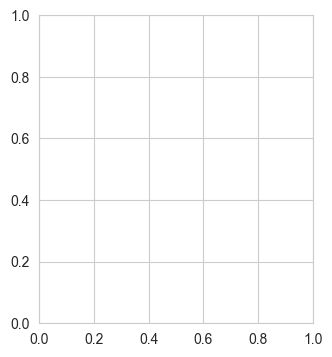

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(data['cholesterol'], bins=5, color='skyblue')
plt.title('Cholesterol Distribution')

plt.subplot(1, 3, 2)
plt.hist(data['gluc'], bins=5, color='lightgreen')
plt.title('Glucose Distribution')

plt.subplot(1, 3, 3)
plt.hist(data['ap_hi'], bins=10, color='lightcoral')
plt.title('Blood Pressure Distribution')

plt.tight_layout()
plt.show()

# **OVERALL ANALYSIS USING PIE CHART**

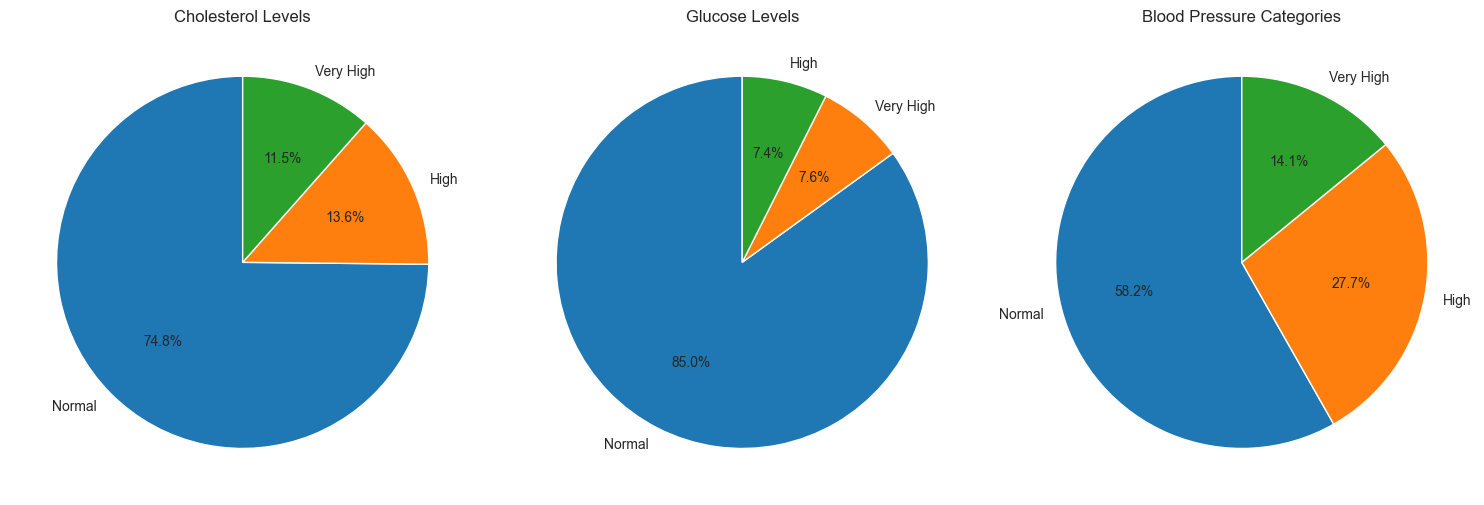

In [ ]:


# Calculate blood pressure category
data['bp_category'] = pd.cut(data['ap_hi'], bins=[0, 120, 140, float('inf')],
                                   labels=['Normal', 'High', 'Very High'])

# Map numerical values to labels for cholesterol and glucose
cholesterol_map = {1: 'Normal', 2: 'High', 3: 'Very High'}
glucose_map = {1: 'Normal', 2: 'High', 3: 'Very High'}
data['cholesterol'] = data['cholesterol'].map(cholesterol_map)
data['gluc'] = data['gluc'].map(glucose_map)

# Calculate ratios for each metric
cholesterol_ratios =data['cholesterol'].value_counts(normalize=True)
glucose_ratios = data['gluc'].value_counts(normalize=True)
bp_ratios =data['bp_category'].value_counts(normalize=True)

# Create pie charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].pie(cholesterol_ratios, labels=cholesterol_ratios.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Cholesterol Levels')

axes[1].pie(glucose_ratios, labels=glucose_ratios.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Glucose Levels')

axes[2].pie(bp_ratios, labels=bp_ratios.index, autopct='%1.1f%%', startangle=90)
axes[2].set_title('Blood Pressure Categories')

plt.tight_layout()
plt.show()

# **PLOTTING OF SMOKING STATUS AND ALCOHOL CONSUMPTION OF EMPLOYEES BY GENDER**

C:\Users\sarth\AppData\Local\Temp\ipykernel_16640\442159784.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Male', 'Female'])  # Set x-tick labels
C:\Users\sarth\AppData\Local\Temp\ipykernel_16640\442159784.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Male', 'Female'])  # Set x-tick labels


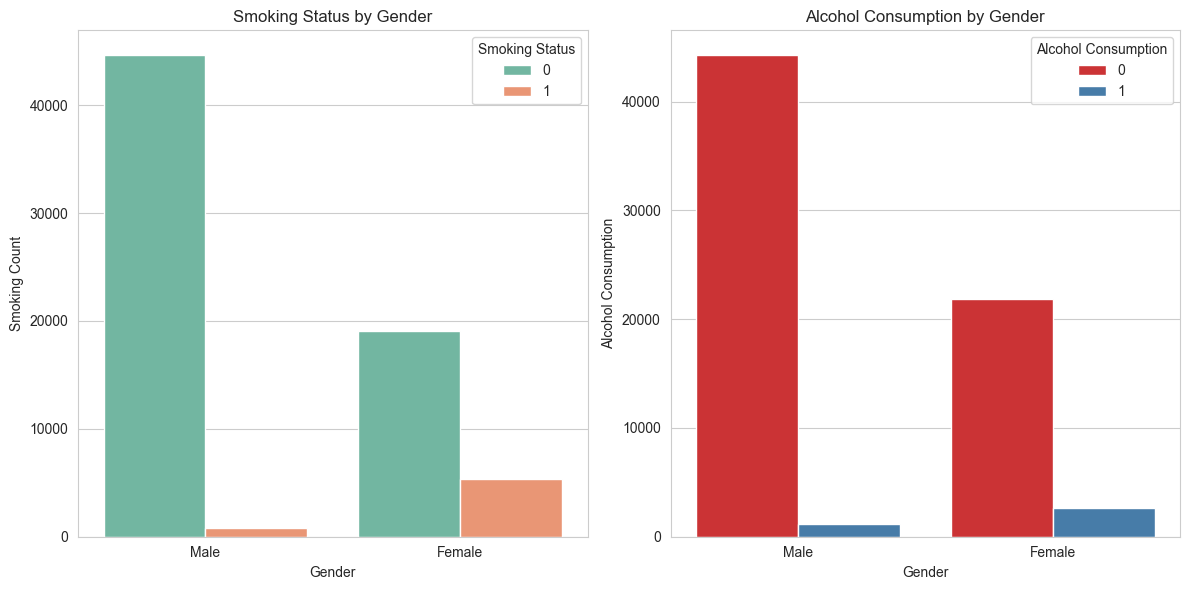

In [ ]:


# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Smoking Status by Gender
sns.countplot(data=data, x='gender', hue='smoke', ax=axes[0], palette='Set2')
axes[0].set_title('Smoking Status by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Smoking Count')
axes[0].legend(title='Smoking Status')
axes[0].set_xticklabels(['Male', 'Female'])  # Set x-tick labels
# Plot 2: Alcohol Consumption by Gender
sns.countplot(data=data, x='gender', hue='alco', ax=axes[1], palette='Set1')
axes[1].set_title('Alcohol Consumption by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Alcohol Consumption')
axes[1].legend(title='Alcohol Consumption')
axes[1].set_xticklabels(['Male', 'Female'])  # Set x-tick labels

plt.tight_layout()
plt.show()



## **ANALYSIS OF EMPLOYEES SMOKING AND CONSUMING ALCOHOL**

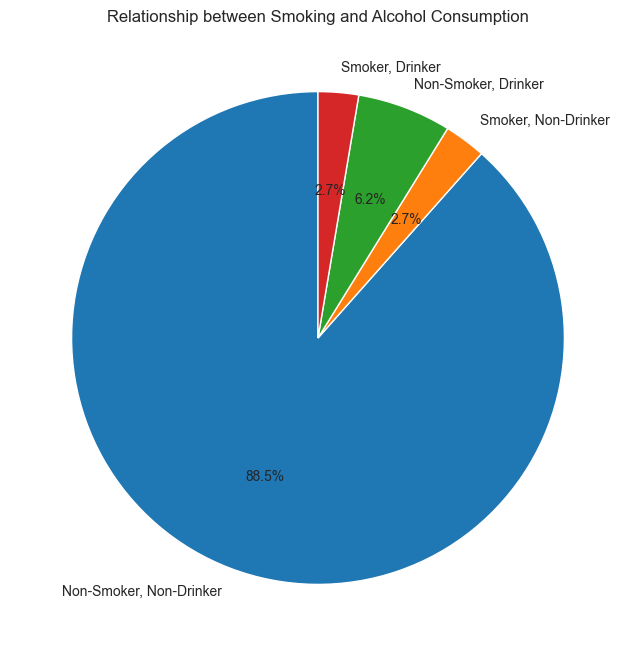

In [ ]:
# Count combinations of smoking and alcohol consumption
combinations = data.groupby(['smoke', 'alco']).size().reset_index(name='count')

# Create labels for the pie chart
labels = [
    'Non-Smoker, Non-Drinker',
    'Smoker, Non-Drinker',
    'Non-Smoker, Drinker',
    'Smoker, Drinker'
]

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(combinations['count'], labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Relationship between Smoking and Alcohol Consumption')
plt.show()

## **Comparison of physically active employees and non-physically active employees vs CVD with grouped bar chart with percentages**

<Figure size 1000x1200 with 0 Axes>

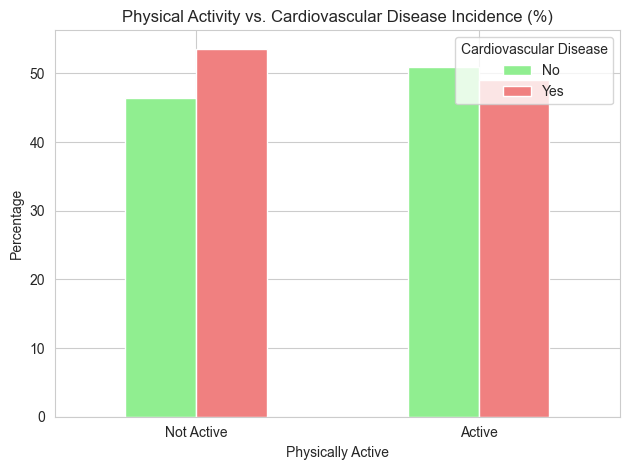

In [ ]:

# Group data and calculate percentages
grouped = data.groupby(['active', 'cardio'])['cardio'].count().unstack().fillna(0)
percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100

# Plot grouped bar chart
plt.figure(figsize=(10, 12))
percentages.plot(kind='bar', color=['lightgreen', 'lightcoral'])
plt.title('Physical Activity vs. Cardiovascular Disease Incidence (%)')
plt.xlabel('Physically Active')
plt.xticks([0, 1], ['Not Active', 'Active'], rotation=0)
plt.ylabel('Percentage')
plt.legend(title='Cardiovascular Disease', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

## **Analysis using donat chart of employees alcohol intake vs CVD**

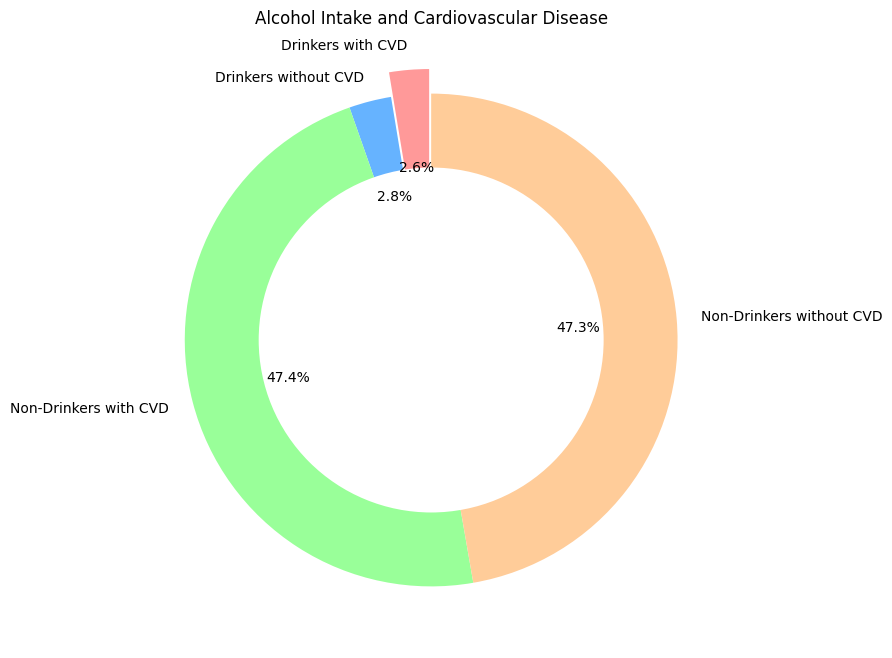

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
health_data = pd.read_csv('/content/Health Screening Data.csv')

# Calculate counts for each combination
alco_cardio = health_data[(health_data['alco'] == 1) & (health_data['cardio'] == 1)].shape[0]
alco_no_cardio = health_data[(health_data['alco'] == 1) & (health_data['cardio'] == 0)].shape[0]
no_alco_cardio = health_data[(health_data['alco'] == 0) & (health_data['cardio'] == 1)].shape[0]
no_alco_no_cardio = health_data[(health_data['alco'] == 0) & (health_data['cardio'] == 0)].shape[0]

# Create labels and sizes
labels = ['Drinkers with CVD', 'Drinkers without CVD', 'Non-Drinkers with CVD', 'Non-Drinkers without CVD']
sizes = [alco_cardio, alco_no_cardio, no_alco_cardio, no_alco_no_cardio]
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

# Explode the first slice (Drinkers with CVD)
explode = (0.1, 0, 0, 0)

# Plot donut chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Alcohol Intake and Cardiovascular Disease')

# Draw a circle at the center to create a donut chart
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.show()

# **SCATTER PLOT GRAPH SHOWING THE CORRELATION BETWEEN BMI AND BLOOD PRESSURE SYSTOLIC**

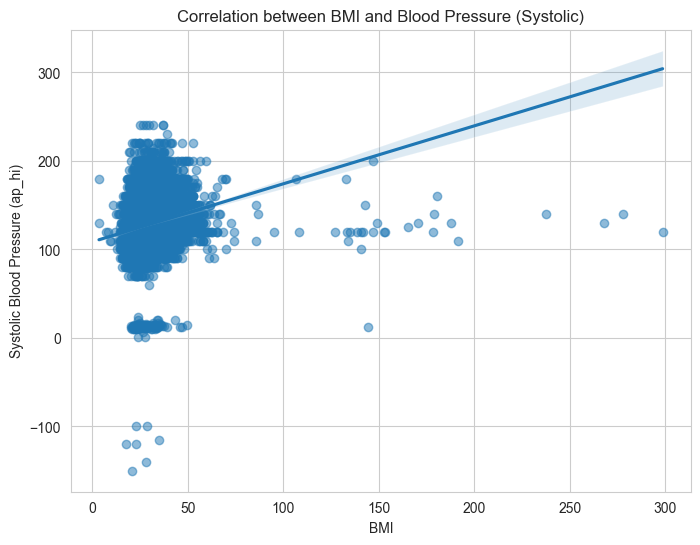

Correlation coefficient: 0.2190237481881115


In [ ]:

# Check if 'bmi' column exists, and if not, handle the error
if 'BMI' in data.columns:
    # Create a scatter plot with regression line
    plt.figure(figsize=(8, 6))
    sns.regplot(x='BMI', y='ap_hi', data=data, scatter_kws={'alpha':0.5})
    plt.title('Correlation between BMI and Blood Pressure (Systolic)')
    plt.xlabel('BMI')
    plt.ylabel('Systolic Blood Pressure (ap_hi)')
    plt.show()

    # Calculate the correlation coefficient
    correlation = data['BMI'].corr(data['ap_hi'])
    print("Correlation coefficient:", correlation)
else:
    print("Error: 'BMI' column not found in the dataset.")
    # Investigate further to understand why the column is missing
    print(data.columns) # Print available columns to verify